# Download the Data

In [1]:
!pip3 install tqdm
!pip3 install pillow --upgrade

  Using cached pillow-12.1.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
Using cached pillow-12.1.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.0 MB)
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.4.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-multimodal 1.4.0 requires Pillow<12,>=10.0.1, but you have pillow 12.1.0 which is incompatible.
autogluon-multimodal 1.4.0 requires transformers[sentencepiece]<4.50,>=4.38.0, but you have transformers 4.57.1 which is incompatible.
strands-agents-tools 0.1.9 requires pillow<12.0.0,>=11.2.1, but you have pillow 12.1.0 which is incompatible.


In [2]:
%matplotlib inline

import os
import io
import tarfile
import urllib
import shutil
import json
import random
import numpy as np
import boto3
import sagemaker

from tqdm import tqdm
from sagemaker.amazon.amazon_estimator import get_image_uri
from matplotlib import pyplot as plt
from xml.etree import ElementTree as ET
from PIL import Image, ImageDraw, ImageFont

sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


In [6]:
def download_and_extract(data_dir, download_dir):
    for url in urls:
        target_file = url.split('/')[-1]
        file_path = os.path.join(download_dir, target_file)

        if not os.path.exists(file_path):
            print('Downloading', url)
            urllib.request.urlretrieve(url, file_path)
        else:
            print('Already downloaded', url)

        # Always extract
        print("Extracting", target_file)
        with tarfile.open(file_path) as tf:
            tf.extractall(data_dir)

In [ ]:
os.makedirs('data', exist_ok=True)
download_and_extract('data', '.')


Already downloaded http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Extracting images.tar.gz
Already downloaded http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Extracting annotations.tar.gz


# Visualize Data

In [3]:
trimaps_dir = 'data/annotations/trimaps/'

maps = [x for x in os.listdir(trimaps_dir) if x[-3:] == 'png']
print(len(maps))

12116


In [4]:
image_dir = 'data/images/'

images = [x for x in os.listdir(image_dir) if x[-3:] == 'jpg']
print(len(images))

7390


In [5]:
images[0]

'Abyssinian_1.jpg'

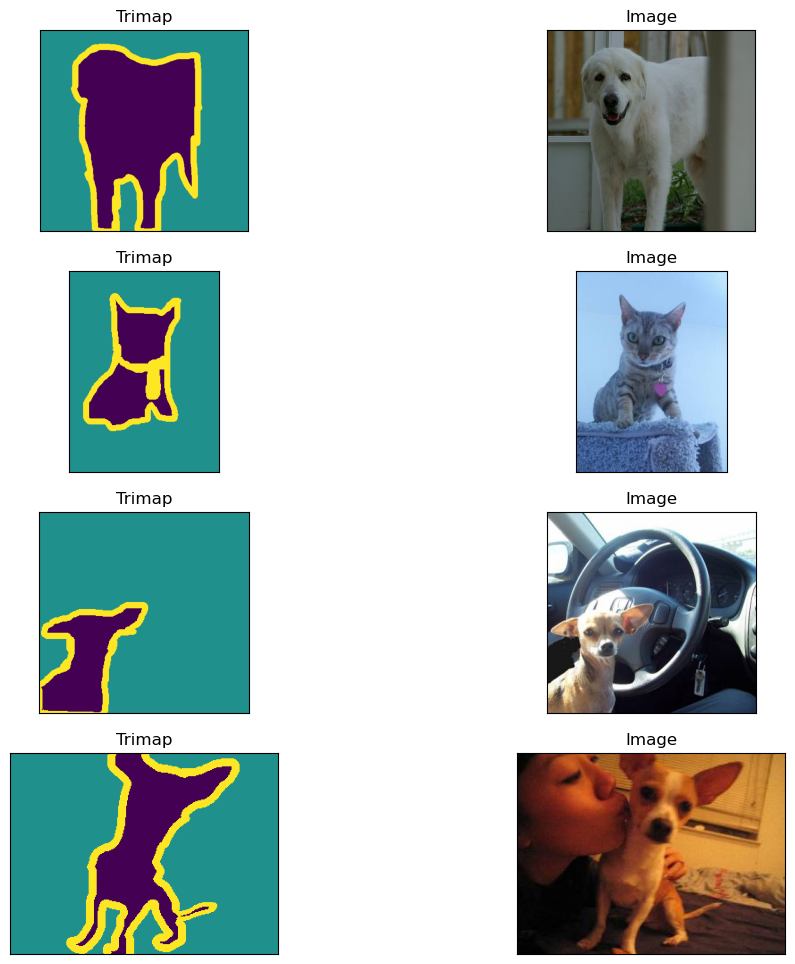

In [7]:
with open('data/annotations/trainval.txt') as f:
    valid_images = [line.split()[0] for line in f]

plt.figure(figsize=(12, 12))

for i in range(4):
    base = random.choice(valid_images)

    image_name = base + '.jpg'
    map_name = base + '.png'

    plt.subplot(4, 2, 1 + i*2)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(plt.imread(os.path.join(trimaps_dir, map_name)))
    plt.title('Trimap')

    plt.subplot(4, 2, 2 + i*2)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(plt.imread(os.path.join(image_dir, image_name)))
    plt.title('Image')

plt.show()


In [9]:
maps = [
    f for f in os.listdir(trimaps_dir)
    if f.endswith('.png') and not f.startswith('._')
]

img = Image.open(os.path.join(trimaps_dir, maps[0]))
img = np.array(img)

print(np.unique(img))

[1 2 3]


# SageMaker Setup

In [21]:
role = sagemaker.get_execution_role()
bucket_name = 'amazon-sagemaker-931324892365-eu-north-1-d0mbzagw19oihf'
training_image = get_image_uri(boto3.Session().region_name, 'semantic-segmentation', repo_version='latest')
print(training_image)

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
669576153137.dkr.ecr.eu-north-1.amazonaws.com/semantic-segmentation:1


In [11]:
folders = ['train', 'train_annotation', 'validation', 'validation_annotation']

for folder in folders:
    if os.path.isdir(folder):
        shutil.rmtree(folder)
    os.mkdir(folder)

# Preparing Data for SageMaker

In [ ]:
random.seed(42)

# trimap basenames without extension
valid_basenames = {
    os.path.splitext(f)[0]
    for f in maps
}

valid_images = [
    img for img in images
    if os.path.splitext(img)[0] in valid_basenames
]

def get_map_file(image):
    return os.path.splitext(image)[0] + '.png'

for image in tqdm(valid_images):
    target_set = 'train' if random.random() < 0.75 else 'validation'

    image_file_path = os.path.join('data/images', image)
    image_target_path = os.path.join(target_set, image)

    map_name = get_map_file(image)
    map_file_path = os.path.join(trimaps_dir, map_name)
    map_target_path = os.path.join(target_set + '_annotation', map_name)

    shutil.copy(image_file_path, image_target_path)
    shutil.copy(map_file_path, map_target_path)


100%|██████████| 6058/6058 [54:12<00:00,  1.86it/s]  


In [14]:
train_images = os.listdir('train')
train_annots = os.listdir('train_annotation')

In [15]:
print(len(train_annots), len(train_images))

4938 4938


# Uploading Data to S3

In [22]:
sess = sagemaker.Session()
print('Starting upload')

s3_train_path = sess.upload_data(path='train', bucket=bucket_name, key_prefix='train')
print('Training images uploaded')

s3_train_path = sess.upload_data(path='train_annotation', bucket=bucket_name, key_prefix='train_annotation')
print('Training annotations uploaded')

s3_train_path = sess.upload_data(path='validation', bucket=bucket_name, key_prefix='validation')
print('Validation images uploaded')

s3_train_path = sess.upload_data(path='validation_annotation', bucket=bucket_name, key_prefix='validation_annotation')
print('Validation annotations uploaded')

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Starting upload
Training images uploaded
Training annotations uploaded
Validation images uploaded
Validation annotations uploaded


In [19]:
print(role)

arn:aws:iam::931324892365:role/service-role/AmazonSageMakerAdminIAMExecutionRole


# SageMaker Estimator

In [45]:
from sagemaker.estimator import Estimator

model = Estimator(
    image_uri=training_image,
    role=role,
    instance_count=1,
    instance_type='ml.p2.xlarge',
    volume_size=100,
    max_run=36000,
    input_mode='File',
    output_path="s3://amazon-sagemaker-931324892365-eu-north-1-d0mbzagw19oihf/segmentation-output",
    sagemaker_session=sess
)


sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment


# Hyperparameters

In [46]:
model.set_hyperparameters(
    backbone='resnet50',
    algorithm='FCN',
    crop_size=224,
    num_classes=3,
    epochs=10,
    learning_rate=0.0001,
    optimizer='adam',
    lr_scheduler='poly',
    mini_batch_size=16,
    validation_mini_batch_size=16,
    num_training_sample=len(train_images)
)

# Data Channels

In [27]:
bucket = 'amazon-sagemaker-931324892365-eu-north-1-d0mbzagw19oihf'

s3_train_path = f's3://{bucket}/train'
s3_train_annotation_path = f's3://{bucket}/train_annotation'

s3_validation_path = f's3://{bucket}/validation'
s3_validation_annotation_path = f's3://{bucket}/validation_annotation'


In [28]:
from sagemaker.inputs import TrainingInput

train_data = TrainingInput(
    s3_data=s3_train_path,
    distribution='FullyReplicated',
    content_type='image/jpeg'
)

train_annotation_data = TrainingInput(
    s3_data=s3_train_annotation_path,
    distribution='FullyReplicated',
    content_type='image/png'
)

validation_data = TrainingInput(
    s3_data=s3_validation_path,
    distribution='FullyReplicated',
    content_type='image/jpeg'
)

validation_annotation_data = TrainingInput(
    s3_data=s3_validation_annotation_path,
    distribution='FullyReplicated',
    content_type='image/png'
)


In [47]:
model.fit({
    'train': train_data,
    'train_annotation': train_annotation_data,
    'validation': validation_data,
    'validation_annotation': validation_annotation_data
})


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 model.fit({                                                                                  │
│   2 │   'train': train_data,                                                                     │
│   3 │   'train_annotation': train_annotation_data,                                               │
│   4 │   'validation': validation_data,                                                           │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/telemetry/telemetry_logging.py:171 in wrapper  │
│                                                                                                  │
│   168 │   │   │   │   │   caught_ex = e                                                          │
│   169 │   │   │   │   finally:                                                                   │
│   170 │   │   │   │   │   if caught_ex:                                                          │
│ ❱ 171 │   │   │   │   │   │   raise caught_ex                                                    │
│   172 │   │   │   │   │   return response  # pylint: disable=W0150                               │
│   173 │   │   │   else:                                                                          │
│   174 │   │   │   │   logger.debug(                                                              │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/telemetry/telemetry_logging.py:142 in wrapper  │
│                                                                                                  │
│   139 │   │   │   │   start_timer = perf_counter()                                               │
│   140 │   │   │   │   try:                                                                       │
│   141 │   │   │   │   │   # Call the original function                                           │
│ ❱ 142 │   │   │   │   │   response = func(*args, **kwargs)                                       │
│   143 │   │   │   │   │   stop_timer = perf_counter()                                            │
│   144 │   │   │   │   │   elapsed = stop_timer - start_timer                                     │
│   145 │   │   │   │   │   extra += f"&x-latency={round(elapsed, 2)}"                             │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/workflow/pipeline_context.py:346 in wrapper    │
│                                                                                                  │
│   343 │   │   │                                                                                  │
│   344 │   │   │   return _StepArguments(retrieve_caller_name(self_instance), run_func, *args,    │
│   345 │   │                                                                                      │
│ ❱ 346 │   │   return run_func(*args, **kwargs)                                                   │
│   347 │                                                                                          │
│   348 │   return wrapper                                                                         │
│   349                                                                                            │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/estimator.py:1422 in fit                       │
│                                                            

In [48]:
import sagemaker
from sagemaker import image_uris

# 1. Retrieve the correct docker image for Semantic Segmentation (CPU version)
training_image = image_uris.retrieve(
    region=sess.boto_region_name,
    framework='semantic-segmentation', 
    image_scope='training',
    instance_type='ml.m5.2xlarge'  # Ensures you get the CPU-compatible image
)

# 2. Define the Estimator (Standard Setup)
segmentation_model = sagemaker.estimator.Estimator(
    image_uri=training_image,
    role=role,
    instance_count=1,
    instance_type='ml.m5.2xlarge', # CPU instance
    volume_size=100,
    max_run=36000,
    output_path="s3://amazon-sagemaker-931324892365-eu-north-1-d0mbzagw19oihf/segmentation-output",
    sagemaker_session=sess
)

sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment


In [49]:
segmentation_model.set_hyperparameters(
    backbone='resnet-50',     # Options: 'resnet-50', 'resnet-101', 'mobilenet-v2'
    algorithm='fcn',          # Options: 'fcn', 'psp', 'deeplab-v3'
    num_classes=3,           
    num_training_samples=len(train_images),
    epochs=10,                
    learning_rate=0.0001,
    optimizer='rmsprop',
    mini_batch_size=4,        
    validation_mini_batch_size=4
)

In [50]:
segmentation_model.fit({
    'train': train_data,
    'train_annotation': train_annotation_data,
    'validation': validation_data,
    'validation_annotation': validation_annotation_data
})


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 segmentation_model.fit({                                                                     │
│   2 │   'train': train_data,                                                                     │
│   3 │   'train_annotation': train_annotation_data,                                               │
│   4 │   'validation': validation_data,                                                           │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/telemetry/telemetry_logging.py:171 in wrapper  │
│                                                                                                  │
│   168 │   │   │   │   │   caught_ex = e                                                          │
│   169 │   │   │   │   finally:                                                                   │
│   170 │   │   │   │   │   if caught_ex:                                                          │
│ ❱ 171 │   │   │   │   │   │   raise caught_ex                                                    │
│   172 │   │   │   │   │   return response  # pylint: disable=W0150                               │
│   173 │   │   │   else:                                                                          │
│   174 │   │   │   │   logger.debug(                                                              │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/telemetry/telemetry_logging.py:142 in wrapper  │
│                                                                                                  │
│   139 │   │   │   │   start_timer = perf_counter()                                               │
│   140 │   │   │   │   try:                                                                       │
│   141 │   │   │   │   │   # Call the original function                                           │
│ ❱ 142 │   │   │   │   │   response = func(*args, **kwargs)                                       │
│   143 │   │   │   │   │   stop_timer = perf_counter()                                            │
│   144 │   │   │   │   │   elapsed = stop_timer - start_timer                                     │
│   145 │   │   │   │   │   extra += f"&x-latency={round(elapsed, 2)}"                             │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/workflow/pipeline_context.py:346 in wrapper    │
│                                                                                                  │
│   343 │   │   │                                                                                  │
│   344 │   │   │   return _StepArguments(retrieve_caller_name(self_instance), run_func, *args,    │
│   345 │   │                                                                                      │
│ ❱ 346 │   │   return run_func(*args, **kwargs)                                                   │
│   347 │                                                                                          │
│   348 │   return wrapper                                                                         │
│   349                                                                                            │
│                                                                                                  │
│ /opt/conda/lib/python3.11/site-packages/sagemaker/estimator.py:1422 in fit                       │
│                                                            

In [59]:
%%writefile train.py
import argparse
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np

# --- 1. Dataset Class ---
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.images = sorted(glob.glob(os.path.join(image_dir, '*')))
        self.masks = sorted(glob.glob(os.path.join(mask_dir, '*')))
        
        if len(self.images) != len(self.masks):
            print(f"Warning: Found {len(self.images)} images and {len(self.masks)} masks.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.images[idx]).convert("RGB")
            mask = Image.open(self.masks[idx])
            
            # Resize
            resize = transforms.Resize((256, 256)) 
            image = resize(image)
            mask = resize(mask)

            # Convert
            image = transforms.ToTensor()(image)
            mask = torch.from_numpy(np.array(mask)).long() 
            
            return image, mask
        except Exception as e:
            print(f"Error loading file index {idx}: {e}")
            return torch.zeros(3, 256, 256), torch.zeros(256, 256).long()

def train():
    parser = argparse.ArgumentParser()
    parser.add_argument('--epochs', type=int, default=1)
    parser.add_argument('--batch-size', type=int, default=4)
    parser.add_argument('--lr', type=float, default=0.001)
    
    parser.add_argument('--train', type=str, default=os.environ.get('SM_CHANNEL_TRAIN'))
    parser.add_argument('--train_annotation', type=str, default=os.environ.get('SM_CHANNEL_TRAIN_ANNOTATION'))
    parser.add_argument('--validation', type=str, default=os.environ.get('SM_CHANNEL_VALIDATION'))
    parser.add_argument('--validation_annotation', type=str, default=os.environ.get('SM_CHANNEL_VALIDATION_ANNOTATION'))
    parser.add_argument('--model-dir', type=str, default=os.environ.get('SM_MODEL_DIR'))
    
    args, _ = parser.parse_known_args()

    device = torch.device("cpu")
    print(f"Training on device: {device}")
    
    # --- 2. Load Data ---
    train_dataset = SegmentationDataset(args.train, args.train_annotation)
    val_dataset = SegmentationDataset(args.validation, args.validation_annotation)
    
    # drop_last=True ensures we never have a batch of size 1
    train_loader = DataLoader(
        train_dataset, 
        batch_size=args.batch_size, 
        shuffle=True, 
        drop_last=True  
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=args.batch_size, 
        shuffle=False,
        drop_last=True
    )

    # --- 3. Load MobileNetV3 (num_classes=4) ---
    print(f"Loading MobileNetV3 with num_classes=3...")
    model = models.segmentation.deeplabv3_mobilenet_v3_large(weights=None, num_classes=4)
    model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.CrossEntropyLoss()

    # --- 4. Training Loop ---
    for epoch in range(args.epochs):
        model.train()
        print(f"--- Epoch {epoch+1}/{args.epochs} ---")
        
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)['out']
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if batch_idx % 5 == 0:
                print(f"Batch {batch_idx}: Loss = {loss.item():.4f}")

        # Check if loader was empty (edge case for very small datasets)
        if len(train_loader) > 0:
            epoch_loss = running_loss / len(train_loader)
            print(f"Epoch {epoch+1} Avg Loss: {epoch_loss:.4f}")
        else:
            print("Epoch skipped (Dataset smaller than batch size?)")

    # --- 5. Save Model ---
    path = os.path.join(args.model_dir, 'model.pth')
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")

if __name__ == '__main__':
    train()

Overwriting train.py


# Model Training

In [ ]:
from sagemaker.pytorch import PyTorch

# Estimator Definition
estimator = PyTorch(
    entry_point='train.py',
    source_dir='.',
    role=role,
    instance_count=1,
    instance_type='ml.m5.2xlarge', # CPU Instance
    framework_version='2.0.0',
    py_version='py310',
    output_path=f"s3://{bucket}/segmentation-output",
    sagemaker_session=sess,
    hyperparameters={
        'epochs': 2,        # Set low for testing
        'batch-size': 2     # Keep small for CPU
    }
)

# Connect inputs to channels
# Note keys map to arguments in train.py (e.g., 'train' -> --train)
estimator.fit({
    'train': train_data,
    'train_annotation': train_annotation_data,
    'validation': validation_data,
    'validation_annotation': validation_annotation_data
})

sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment
2026-01-15 17:17:28 Starting - Starting the training job...
2026-01-15 17:17:43 Starting - Preparing the instances for training...
2026-01-15 17:18:05 Downloading - Downloading input data............
2026-01-15 17:20:11 Training - Training image download completed. Training in progress.bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2026-01-15 17:20:12,601 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2026-01-15 17:20:12,601 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-01-15 17:20:12,602 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-01-15 17:20:12,610 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2026-01-15 17:20:12,612 sagemaker_pytorch_container.training IN

# Deploy Model

In [63]:
%%writefile inference.py
import torch
import os
import io
import json
from torchvision import models, transforms
from PIL import Image

# 1. Load the Model (Run once when endpoint starts)
def model_fn(model_dir):
    device = torch.device("cpu")
    print("Loading model...")
    
    # Must match the architecture used in training exactly
    model = models.segmentation.deeplabv3_mobilenet_v3_large(num_classes=4)
    
    # Load the weights saved in model.pth
    path = os.path.join(model_dir, 'model.pth')
    model.load_state_dict(torch.load(path, map_location=device))
    
    model.to(device).eval()
    print("Model loaded successfully.")
    return model

# 2. Process Input (Runs for every request)
def input_fn(request_body, request_content_type):
    if request_content_type == 'application/x-image':
        # Convert bytes to PIL Image
        return Image.open(io.BytesIO(request_body)).convert("RGB")
    else:
        raise ValueError(f"Unsupported content type: {request_content_type}")

# 3. Predict (Runs for every request)
def predict_fn(input_object, model):
    # Preprocess: Resize to match training size (256x256)
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    
    input_tensor = preprocess(input_object).unsqueeze(0) # Add batch dimension
    
    with torch.no_grad():
        output = model(input_tensor)['out'][0]
        
    # Get the predicted class for each pixel (argmax)
    prediction = output.argmax(0).byte().cpu().numpy()
    
    return prediction.tolist() # Return as standard JSON list

# 4. Format Output
def output_fn(prediction, response_content_type):
    return json.dumps(prediction)

Overwriting inference.py


In [ ]:
from sagemaker.pytorch import PyTorchModel

# Get the location of the trained model artifact from your estimator
# If you lost the estimator variable, replace this with the string S3 path from your training logs
model_data = estimator.model_data 
print(f"Deploying model from: {model_data}")

# Create the Model Object
pytorch_model = PyTorchModel(
    model_data=model_data,
    role=role,
    entry_point='inference.py',  # The script we just created
    source_dir='.',              # Current directory
    framework_version='2.0.0',
    py_version='py310',
    sagemaker_session=sess
)

# Deploy! (This takes ~5-8 minutes)
predictor = pytorch_model.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.xlarge', # CPU Instance for hosting
    serializer=sagemaker.serializers.IdentitySerializer(content_type='application/x-image'),
    deserializer=sagemaker.deserializers.JSONDeserializer() 
)

Deploying model from: s3://amazon-sagemaker-931324892365-eu-north-1-d0mbzagw19oihf/segmentation-output/pytorch-training-2026-01-15-16-39-04-965/output/model.tar.gz
------!

# Predictions

Sending request...


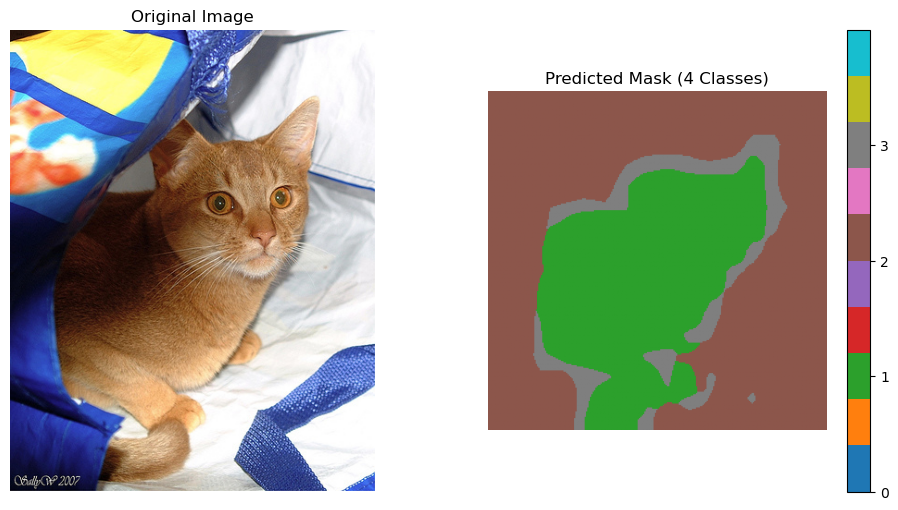

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Pick a validation image locally
image_dir = 'validation' # Ensure this folder exists locally
images = [x for x in os.listdir(image_dir) if x.endswith('.jpg')]

if len(images) > 0:
    image_path = os.path.join(image_dir, images[0])

    # 2. Read image bytes
    with open(image_path, 'rb') as f:
        payload = f.read()

    # 3. Get Prediction
    print("Sending request...")
    response = predictor.predict(payload)
    mask = np.array(response)

    # 4. Visualize
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(plt.imread(image_path))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Predicted Mask (4 Classes)")
    # Using 'jet' or 'tab10' colormap helps distinguish 4 classes better than default
    plt.imshow(mask, cmap='tab10', vmin=0, vmax=4) 
    plt.colorbar(ticks=[0, 1, 2, 3])
    plt.axis('off')

    plt.show()
else:
    print("No images found in local 'validation' folder to test.")

Sending request...


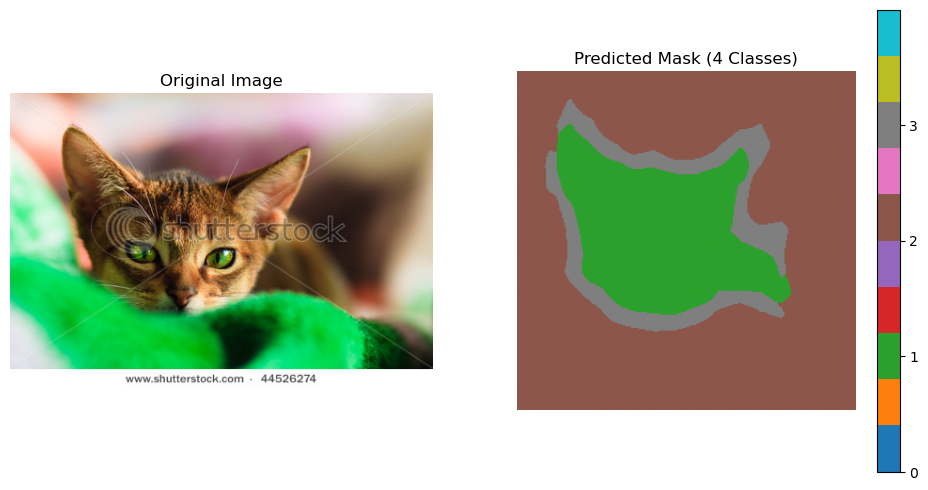

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Pick a validation image locally
image_dir = 'validation' # Ensure this folder exists locally
images = [x for x in os.listdir(image_dir) if x.endswith('.jpg')]

if len(images) > 0:
    image_path = os.path.join(image_dir, images[0])

    # 2. Read image bytes
    with open(image_path, 'rb') as f:
        payload = f.read()

    # 3. Get Prediction
    print("Sending request...")
    response = predictor.predict(payload)
    mask = np.array(response)

    # 4. Visualize
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(plt.imread(image_path))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Predicted Mask (4 Classes)")
    # Using 'jet' or 'tab10' colormap helps distinguish 4 classes better than default
    plt.imshow(mask, cmap='tab10', vmin=0, vmax=4) 
    plt.colorbar(ticks=[0, 1, 2, 3])
    plt.axis('off')

    plt.show()
else:
    print("No images found in local 'validation' folder to test.")

In [68]:
image_dir = 'validation'
images = [x for x in os.listdir(image_dir) if x[-3:] == 'jpg']
print(len(images))

1834


In [70]:
# 1. Tells the endpoint you are sending raw image bytes
predictor.content_type = 'application/x-image'

# 2. Tells the endpoint you expect a JSON list back (the mask array)
predictor.accept = 'application/json'

In [72]:
index = 2

image_path = os.path.join(image_dir, images[index])
# image_path = 'dog_cat.jfif'

with open(image_path, 'rb') as f:
    b = bytearray(f.read())

results = predictor.predict(b)

In [77]:
# Convert directly to numpy (No Image.open needed)
mask = np.array(results)


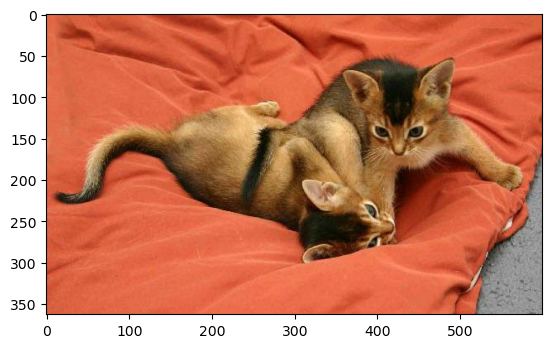

In [78]:
plt.imshow(plt.imread(image_path));

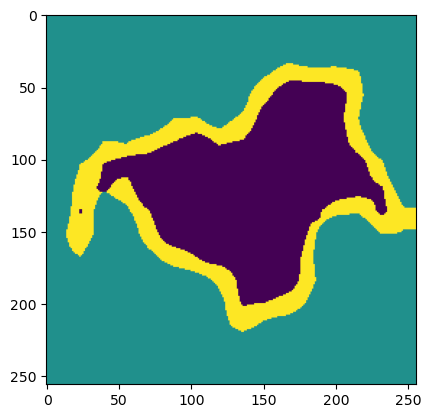

In [79]:
plt.imshow(mask);

Don't forget!! You need to delete endpoint or else you will continue to accrue cost!

In [80]:
predictor.delete_endpoint()